<a href="https://colab.research.google.com/github/Sruteeshsatya/IITG.ai_task_Sruteesh/blob/main/Sruteesh_IITG_ai_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1=pd.read_csv("https://drive.google.com/uc?export=download&id=1cvoLOi5rAfPeENtxWW2NKFVhyr1WoIkL")
df2=pd.read_excel("https://drive.google.com/uc?export=download&id=1zcvzTkGMAlxRTpc9I35IPGubJ_FSyL_U")
df3=pd.read_excel("https://drive.google.com/uc?export=download&id=1UA9xoqljQgi_jgoCHFnbMZRsPhh3jzKo")
df1.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


**We have loaded economic data into df1, Demand data into df2 and natural factors to df3.**

In [ ]:
df1=df1.fillna(0)
solar=df2.loc[df2['solar'].first_valid_index(),'solar']
wind=df2.loc[df2['solar'].first_valid_index(),'solar']
print(solar,wind)

0.0 0.0


**This indicates us that for a long period solar, wind, india_adani, etc which were not given can be taken as 0. As their generation might be negligible throughout the years.**

In [ ]:
df2.fillna(0,inplace=True)
df2=df2.sort_values(by='datetime',ascending=True)
df2=df2.drop(columns='remarks')
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 92650 entries, 24 to 92637
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 92650 non-null  float64       
 9   wind                  92650 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           92650 non-null  float64       
 13  nepal               

**Remarks included information about peaks. It is risky for us as peak will involve looking into future also. Hence we remove.**

In [ ]:
df3.columns=df3.iloc[2,:]
df3=df3.iloc[3:]
df3=df3.sort_values(by='time')
df3['time']=pd.to_datetime(df3['time'])
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107304 entries, 3 to 107306
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   time                            107304 non-null  datetime64[ns]
 1   temperature_2m (°C)             107304 non-null  object        
 2   relative_humidity_2m (%)        107304 non-null  object        
 3   apparent_temperature (°C)       107304 non-null  object        
 4   precipitation (mm)              107304 non-null  object        
 5   dew_point_2m (°C)               107304 non-null  object        
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  object        
 7   wind_direction_10m (°)          107304 non-null  object        
 8   cloud_cover (%)                 107304 non-null  object        
 9   sunshine_duration (s)           107304 non-null  object        
dtypes: datetime64[ns](1), object(9)
memory usage: 8.2+ MB


**We rearrange the columns of natural data**

In [ ]:
df=pd.merge(df2,df3,left_on='datetime',right_on='time',how='outer')
df['datetime']=df['datetime'].combine_first(df['time'])
df=df.drop(columns=['time'])
df=df.sort_values(by='datetime')
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,nepal,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.9,89,13.3,0,12.1,16.4,313,0,0
1,2014-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.6,91,13.2,0,12.1,16,317,0,0
2,2014-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.3,91,12.8,0,11.9,15.7,317,0,0
3,2014-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13,92,12.5,0,11.8,15.4,319,0,0
4,2014-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,12.7,93,12.2,0,11.6,15.2,322,0,0


**It is found out that df3(natural factors data) has no missing rows where as PGCB_demand has few missing rows.**

In [ ]:
cols=list(df.columns)
cols[14:23]=['temperature','humidity','apparent_temperature','precipitation','dewpoint','soil_temperature','wind_direction','cloudcover','sunshine_duration']
df.columns=cols

for col in df.columns:
    if df[col].dtype=='object':
        df[col]=pd.to_numeric(df[col])

df=df[(df['datetime']>='2015-04-19') & (df['datetime']<='2025-01-01 00:00:00')]
df.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,nepal,temperature,humidity,apparent_temperature,precipitation,dewpoint,soil_temperature,wind_direction,cloudcover,sunshine_duration
count,89514,8.846300e+04,88463.000000,88463.000000,88463.000000,8.846300e+04,88463.000000,88463.000000,88463.000000,88463.000000,...,88463.000000,85500.000000,85500.000000,85500.000000,85500.000000,85500.000000,85500.000000,85500.000000,85500.000000,85500.000000
mean,2020-02-12 15:26:18.845767168,9.327041e+03,8686.371127,83.336344,5116.419339,2.083453e+03,865.830675,99.024677,30.053547,1.526118,...,0.006014,25.489386,77.902386,28.952899,0.221572,20.955670,26.651795,191.601135,52.208433,1365.604572
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,8.400000,15.000000,6.600000,0.000000,2.500000,11.700000,1.000000,0.000000,0.000000
25%,2017-08-31 23:15:00,6.741000e+03,6739.000000,0.000000,4412.000000,7.470000e+02,157.000000,44.000000,0.000000,0.000000,...,0.000000,22.800000,69.000000,24.500000,0.000000,16.500000,23.800000,134.000000,3.000000,0.000000
50%,2020-02-09 17:30:00,8.275000e+03,8282.000000,0.000000,5011.000000,1.571000e+03,365.000000,81.000000,0.000000,0.000000,...,0.000000,26.500000,82.000000,31.000000,0.000000,23.200000,27.600000,176.000000,55.000000,0.000000
75%,2022-07-22 04:45:00,1.034850e+04,10412.000000,0.000000,5815.000000,2.496000e+03,932.000000,151.000000,8.000000,0.000000,...,0.000000,28.800000,91.000000,33.800000,0.000000,25.300000,29.800000,276.000000,99.000000,3600.000000
max,2025-01-01 00:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,...,38.000000,40.800000,100.000000,45.600000,43.800000,28.600000,43.500000,360.000000,100.000000,3600.000000
std,NaN,2.169335e+05,2727.611443,452.533345,1151.955441,9.832814e+04,1136.269363,71.982874,83.197602,7.751275,...,0.478008,5.014645,15.589066,6.909663,0.935215,5.131857,4.800902,93.913888,42.387962,1697.100562


**Removal of timestamps after 2024 and before the demand data**

In [ ]:
timediff=(df.iloc[:,0].diff().dt.total_seconds()/60)
irrtime=(timediff==30)
cols=df.columns[1:14]
df.loc[irrtime, cols]=(df[cols].shift(1).values[irrtime]+2*df.loc[irrtime,cols].values)/3

df=df.loc[df['datetime'].dt.minute!=30].reset_index(drop=True)

**Resolved irregular timestamps in the data using weigted average of 2:1 of current and previous. Since we are only taking present and previous hourly data, no data will leak. All 30 min indexes were removed. **

In [ ]:
duplicate=df.duplicated(subset=['datetime']).sum()
print(f"Initial duplicates:{duplicate}")
df=df.groupby('datetime').mean(numeric_only=True).reset_index()
print(f"Final:{df.duplicated(subset=['datetime']).sum()}")

Initial duplicates:419
Final:0



**Followed by, duplicates in data were removed by taaking the mean of all hourly timestamps.**

In [ ]:
cols=df.select_dtypes(include=['number']).columns
df[cols]=df[cols].fillna(df[cols].shift(1).rolling(window=24,min_periods=1).mean())
df[cols]=df[cols].ffill()

range=pd.date_range(start=df['datetime'].min(),end=df['datetime'].max(),freq='h')
missing=range.difference(df['datetime'])
print(len(missing),missing[:10])

0 DatetimeIndex([], dtype='datetime64[ns]', freq='h')


**Initially, it was identified that the PGCBdemand data has missing timestamps. So we use rolling statistics instead of interpolation(as interpolation will involve leaking of future). We replace the missing features by past 24hrs rolling mean.**

113 anomalies are detected


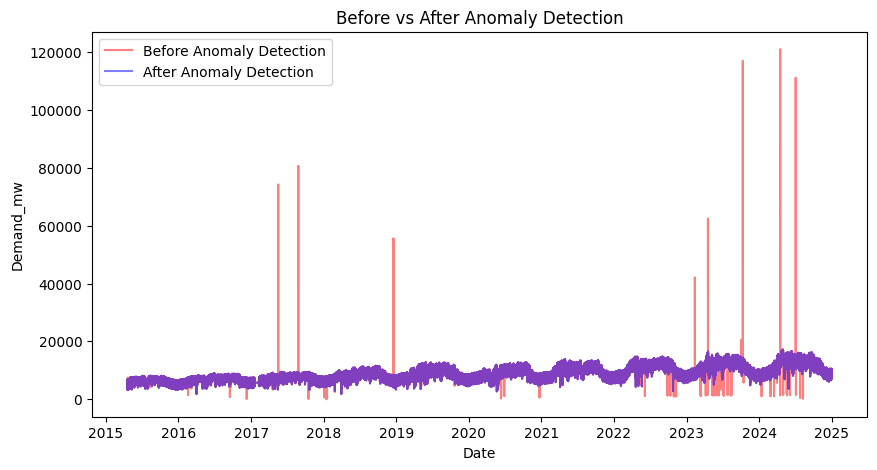

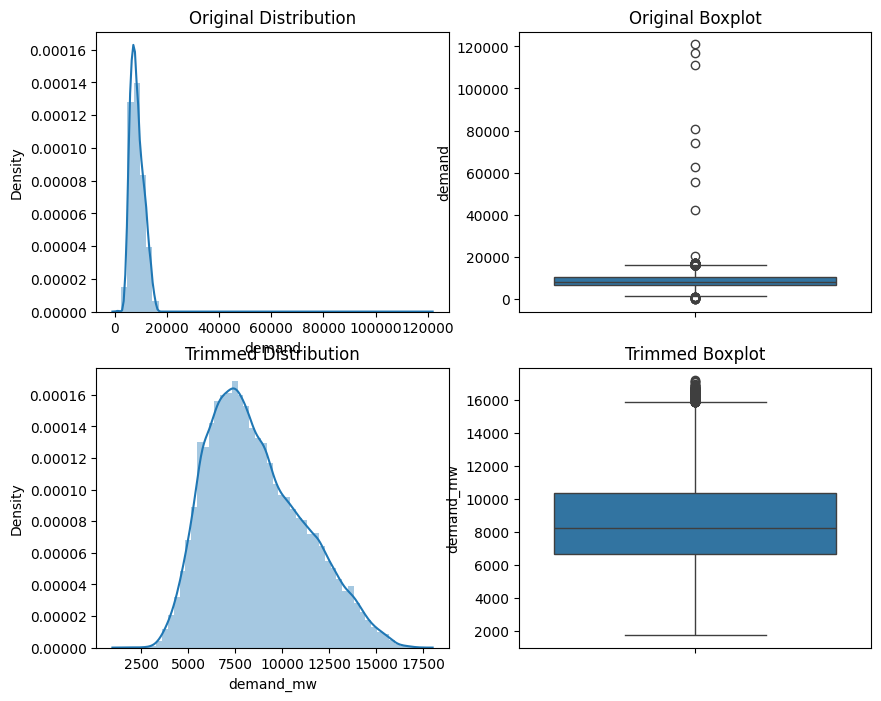

In [ ]:
df['demand']=df['demand_mw'].copy()

zscores=(df['demand_mw']-df['demand_mw'].rolling(window=24).mean())/df['demand_mw'].rolling(window=24).std()
anomalies=zscores.abs()>2.875

print(f"{anomalies.sum()} anomalies are detected")
df.loc[anomalies,'demand_mw']=df['demand_mw'].shift(1).rolling(window=24).median()

plt.rcParams["figure.figsize"]=(10, 5)
plt.plot(df['datetime'],df['demand'], color='red', alpha=0.5, label='Before Anomaly Detection')
plt.plot(df['datetime'],df['demand_mw'], color='blue',alpha=0.5,label='After Anomaly Detection')
plt.title('Before vs After Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Demand_mw')
plt.legend()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['demand'])
plt.title('Original Distribution')
plt.subplot(2,2,2)
sns.boxplot(df['demand'])
plt.title('Original Boxplot')
plt.subplot(2,2,3)
sns.distplot(df['demand_mw'])
plt.title('Trimmed Distribution')
plt.subplot(2,2,4)
sns.boxplot(df['demand_mw'])
plt.title('Trimmed Boxplot')
plt.show()

**We use method of Z-scores to detect anomalies. By keeping threshold value, 2.875 I observed we are able to detect Neither too high nor too low. We smoothem anomalies, by taking the rolling median of past 24hrs(shifed by 1hr)**

In [ ]:
df['hour'] = df['datetime'].dt.hour
df['hoursin']=np.sin(2*np.pi*df['hour']/24)
df['hourcos']=np.cos(2* np.pi* df['hour']/24)

df['dayofweek']=df['datetime'].dt.dayofweek
df['dayofweek']=np.sin(2*np.pi*df['dayofweek']/7)
df['dayofweek']=np.cos(2* np.pi*df['dayofweek']/7)

df['quarter'] = df['datetime'].dt.quarter

df['month'] = df['datetime'].dt.month
df['monthsin']=np.sin(2*np.pi*df['month']/12)
df['monthcos']=np.cos(2*np.pi*df['month']/12)

df['year'] = df['datetime'].dt.year

df['dayofyear']=df['datetime'].dt.dayofyear
df['dayofyearsin']=np.sin(2*np.pi*df['dayofyear']/365.25)
df['dayofyearcos']=np.cos(2* np.pi*df['dayofyear']/365.25)

df['is_weekend']=df['dayofweek'].apply(lambda x:1 if x>=5 else 0)

df['week']=df['datetime'].dt.isocalendar().week.astype(int)
df['weeksin']=np.sin(2*np.pi*df['week']/52)
df['weekcos']=np.cos(2*np.pi*df['week']/52)

seasonmap={12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4}
df['season']=df['month'].map(seasonmap)

**Creation of features as given in the PS. We cyclically encode features like hour, week, dayofyear, month. I learnt this important feature engineering in the last part of resources**

Text(0.5, 1.0, 'Demand vs Temperature')

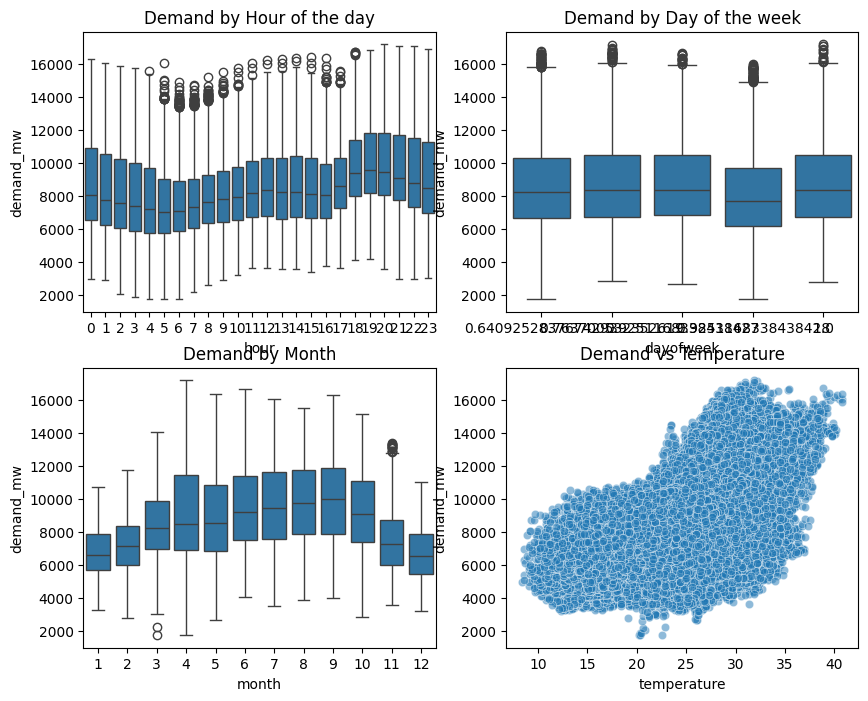

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.boxplot(data = df,x='hour',y='demand_mw')
plt.title("Demand by Hour of the day")
plt.subplot(2,2,2)
sns.boxplot(data = df,x='dayofweek',y='demand_mw')
plt.title("Demand by Day of the week")
plt.subplot(2,2,3)
sns.boxplot(data = df,x='month',y='demand_mw')
plt.title("Demand by Month")
plt.subplot(2,2,4)
sns.scatterplot(data=df,x='temperature',y='demand_mw',alpha=0.5)
plt.title("Demand vs Temperature")

**Some data exploration on important factors.**

In [ ]:
df['demanddaylag']=df['demand_mw'].shift(24)
df['demandweeklag']=df['demand_mw'].shift(168)
df['demandhourlag']=df['demand_mw'].shift(1)
df['demand6hlag']=df['demand_mw'].shift(1)

df['rollingmean24h']=df['demand_mw'].shift(1).rolling(window=24).mean()
df['rollingmean6h']=df['demand_mw'].shift(1).rolling(window=6).mean()
df['rollingstd24h']= df['demand_mw'].shift(1).rolling(window=24).std()
df['rollingstd6h']=df['demand_mw'].shift(1).rolling(window=6).std()


df=df.drop(columns=['demand','dayofweek','month','dayofyear','week'])
df=df.dropna()

**Creation of time features as given in the PS. These help us to see past details and look into past**

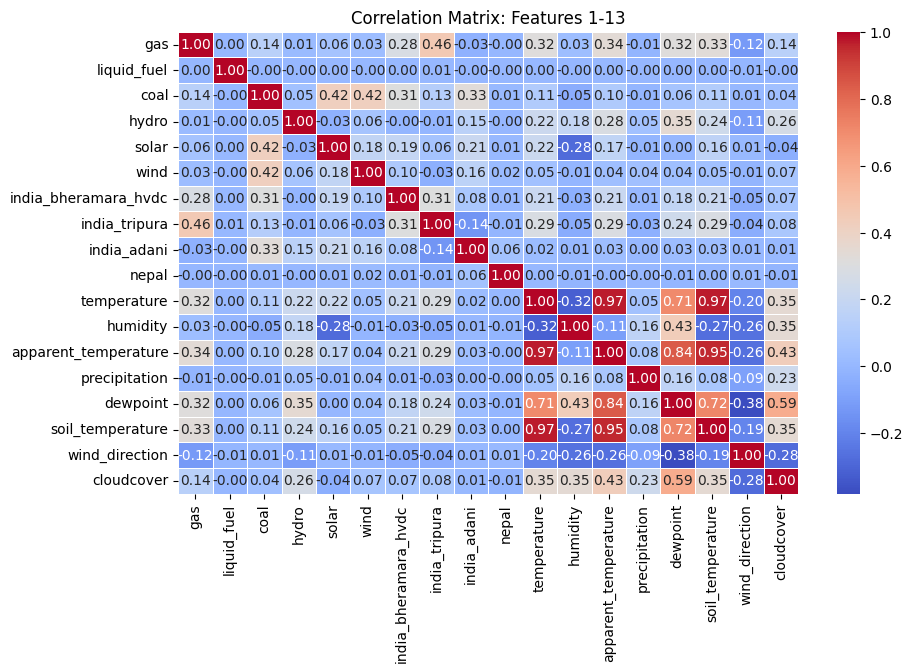

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.iloc[:,4:22].corr(),annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title('Correlation Matrix: Features 1-13')
plt.show()

**Though the initial features are not much corelated, the natural featues are highly corelated. So I created some new features.**

In [ ]:
df['feature1'] = df['sunshine_duration'] / (df['humidity'])

df['feature2']=df['apparent_temperature']*df['dewpoint']

df['feature3']=df['cloudcover']*df['dewpoint']

df['winddirsin']=np.sin(2*np.pi*df['wind_direction']/360)
df['winddircos']=np.cos(2*np.pi*df['wind_direction']/360)

df = df.drop('wind_direction', axis=1)

**Features based on corelation and inverse corelation and cyclic encoding of winddirection**

In [ ]:
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

df["next hour's demand"]=df['demand_mw'].shift(-1)
df=df.drop(df.index[-1])
df1=df1.set_index('Indicator Code')
df1=df1.loc[:,['Indicator Name','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']]
years=list(__builtins__.range(2010,2025))
cols=['Year']+df1.iloc[:,0].tolist()
df4=pd.DataFrame(columns=cols,index=__builtins__.range(len(years)))
df4['Year']=years
for i in __builtins__.range(len(years)):
    df4.iloc[i,1:]=df1.iloc[:,i+1].values
df4=df4.apply(pd.to_numeric,errors='coerce')

df5=pd.merge(df,df4,left_on='year',right_on='Year',how='left')
df5=df5.drop(columns=['Year'])
x=df5.drop(columns=["next hour's demand",'datetime'])
y=df5["next hour's demand"]
xscaled=StandardScaler().fit_transform(x)

lasso=Lasso(alpha=1,random_state=42)
selector=SelectFromModel(lasso)
selector.fit(xscaled,y)
lassofeatures=x.columns[selector.get_support()]
xlasso=x[lassofeatures]

xgb=XGBRegressor(n_estimators=100,learning_rate=0.05,random_state=42)
xgb.fit(xlasso,y)

important=pd.DataFrame({'Feature': lassofeatures,'Importance':xgb.feature_importances_}).sort_values(by='Importance', ascending=False)
indicators=df1['Indicator Name'].unique()
economicimportant=important[important['Feature'].isin(indicators)]
print(economicimportant.head(5))

                                              Feature  Importance
29                                   Urban population    0.002966
53  Foreign direct investment, net outflows (% of ...    0.002134
49  Net financial flows, multilateral (NFL, curren...    0.001139
42  Claims on private sector (annual growth as % o...    0.000990
52         Primary income receipts (BoP, current US$)    0.000692


**We used L1 lasso regression with alpha=1. Which reduced the total features to 60. We used xgb to find feature importance. We observed that the first 4 features are having low but decent importance hence we considered them.**

In [ ]:
codes=['GDP (current US$)','Population, total','Urban population','Access to electricity (% of population)','Manufacturing, value added (% of GDP)','Foreign direct investment, net outflows (% of GDP)']
cols=['Year']+codes
df4=df4.loc[:,cols]
features=[col for col in df4.columns if col!='Year']
df4rolling=df4[features].rolling(window=3).mean()
df4rolling.columns=[f"{col}3yrrollingmean" for col in df4rolling.columns]
df4=pd.concat([df4,df4rolling],axis=1)

df=pd.merge(df,df4,left_on='year',right_on='Year',how='left')
df=df.drop(columns=['Year'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84912 entries, 0 to 84911
Data columns (total 61 columns):
 #   Column                                                            Non-Null Count  Dtype         
---  ------                                                            --------------  -----         
 0   datetime                                                          84912 non-null  datetime64[ns]
 1   generation_mw                                                     84912 non-null  float64       
 2   demand_mw                                                         84912 non-null  float64       
 3   load_shedding                                                     84912 non-null  float64       
 4   gas                                                               84912 non-null  float64       
 5   liquid_fuel                                                       84912 non-null  float64       
 6   coal                                                              8491

**We have taken 5 factors into consideration apart from above ones. Net GDP,Total Population, Percentage of population having electricity access, Manufacturing value(For industrial electricity preferences). We created another dataframe with these as columns and years from 2010 to 2024. We also found the rolling mean of these features of last 3 years. We only took those features, which are relavant and don't capture noise**

In [ ]:
train=df[df['datetime']<'2024-01-01']
test=df[df['datetime']>='2024-01-01']
xtrain=train.drop(columns=['datetime','hour',"next hour's demand"])
ytrain=train["next hour's demand"]

xtest=test.drop(columns=['hour','datetime',"next hour's demand"])
ytest=test["next hour's demand"]

**Splitting of train and test data. 2024 acts as the test. Creation of target(next hour's demand).**

[0]	validation_0-rmse:2261.84668	validation_1-rmse:3510.94812
[100]	validation_0-rmse:892.34836	validation_1-rmse:1358.95277
[200]	validation_0-rmse:432.02574	validation_1-rmse:626.06670
[300]	validation_0-rmse:299.73184	validation_1-rmse:407.69198
[400]	validation_0-rmse:257.51002	validation_1-rmse:340.75948
[500]	validation_0-rmse:235.45321	validation_1-rmse:301.68874
[600]	validation_0-rmse:222.15335	validation_1-rmse:281.87887
[700]	validation_0-rmse:215.00022	validation_1-rmse:273.12998
[800]	validation_0-rmse:209.90119	validation_1-rmse:268.57112
[900]	validation_0-rmse:205.45694	validation_1-rmse:264.73111
[999]	validation_0-rmse:202.06675	validation_1-rmse:262.04392
RMSE:375.06mw
MAPE:2.26%


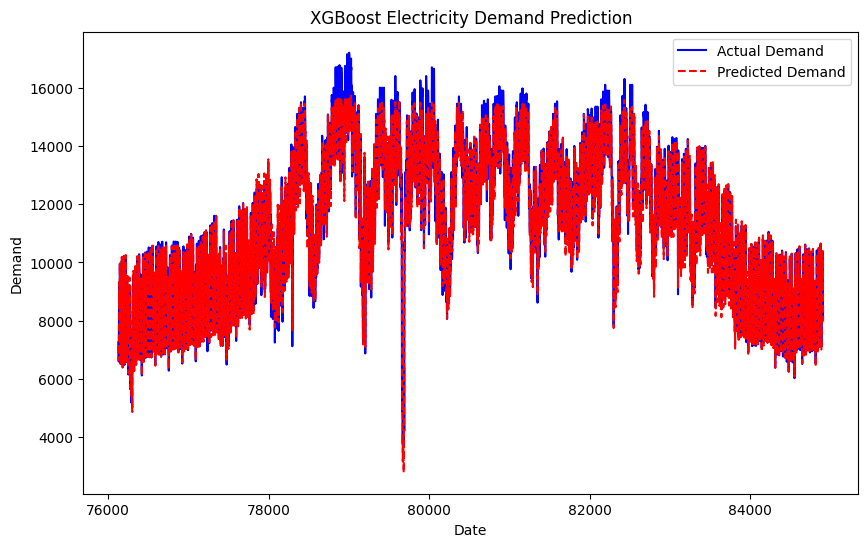

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

model=xgb.XGBRegressor(n_estimators=1000,max_depth=6,learning_rate=0.01,subsample=0.8,colsample_bytree=0.8,
                       objective='reg:squarederror',tree_method='hist',random_state=42,reg_alpha=0.1,reg_lambda=1)

val=int(len(xtrain)*0.95)
xtr,xval=xtrain[:val],xtrain[val:]
ytr,yval=ytrain[:val],ytrain[val:]

model.fit(xtr,ytr,eval_set=[(xtr,ytr),(xval,yval)],verbose=100)
predictions=model.predict(xtest)

rmse=np.sqrt(mean_squared_error(ytest,predictions))
mape=np.mean(np.abs((ytest-predictions)/ytest))*100

print(f"RMSE:{rmse:.2f}mw")
print(f"MAPE:{mape:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,predictions,label='Predicted Demand',color='Red',linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

**I took the validation split at 95% of the data. Because, the training set is very lengthy and we observed that the peaks of demand curve are increasing by years. Xgboost clipped the peaks to the highest during training. Used regularisation hyperparameters which helped to prevent overfitting**

Random Forest RMSE:362.24 MW
Random Forest MAPE:2.23%


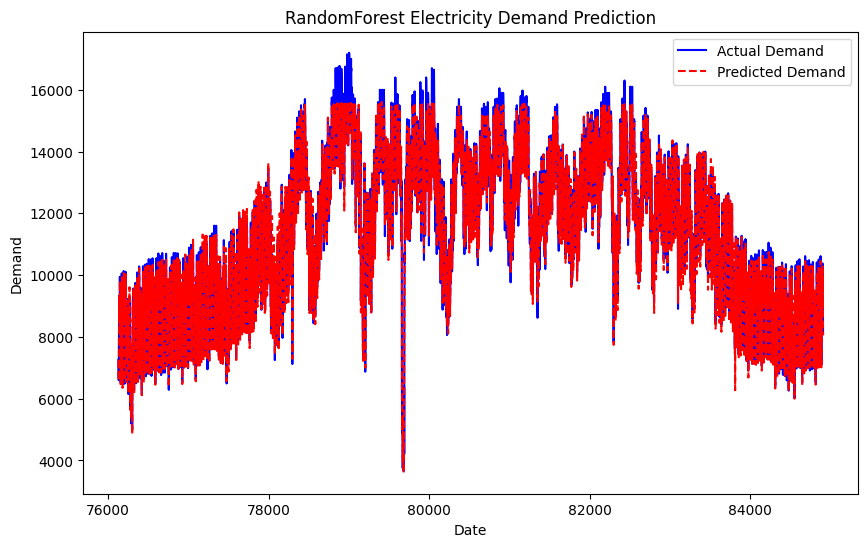

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1)
rf.fit(xtrain, ytrain)
rfpred=rf.predict(xtest)

rmse=np.sqrt(mean_squared_error(ytest,rfpred))
mape=np.mean(np.abs((ytest-rfpred)/ytest))*100
print(f"Random Forest RMSE:{rmse:.2f} MW")
print(f"Random Forest MAPE:{mape:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,rfpred,label='Predicted Demand',color='Red',linestyle='--')
plt.title('RandomForest Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

**Random Forest is giving slightly better result. However the feature importance of Xgboost and are different. Xgboost found more importance in hour(sin and cos) followed by demand and generation. But RF had demand and generation followed by hour. This shows us the fundamental difference of boosting and bagging.**

Linear Regression RMSE:431.71 MW
Linear Regression MAPE:2.76%


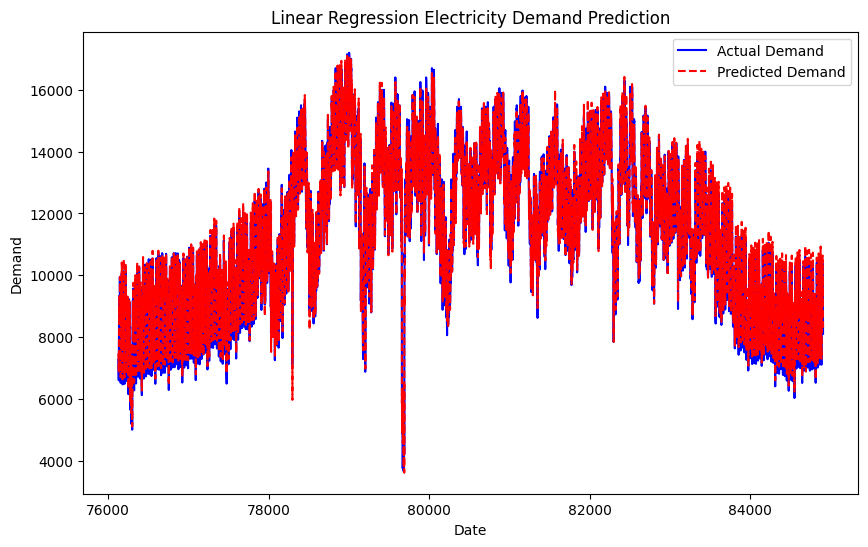

Lasso RMSE:429.17 MW
Ridge RMSE:530.40 MW
Lasso MAPE:2.78%
Ridge MAPE:4.03%


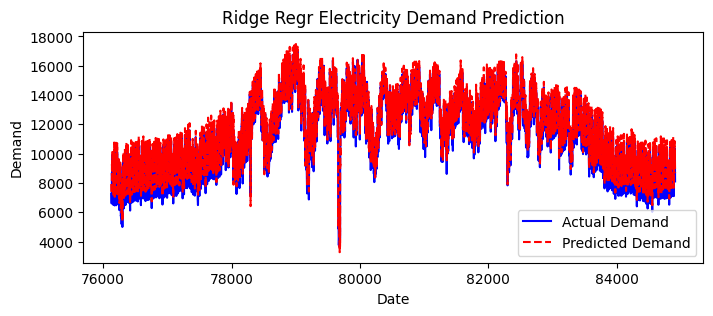

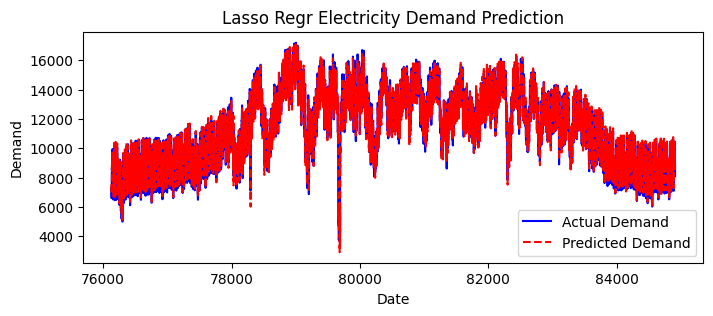

In [ ]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

regr=linear_model.LinearRegression()
regr.fit(xtrain, ytrain)
linearpred=regr.predict(xtest)

rmse=np.sqrt(mean_squared_error(ytest,linearpred))
mape=np.mean(np.abs((ytest-linearpred)/ytest))*100
print(f"Linear Regression RMSE:{rmse:.2f} MW")
print(f"Linear Regression MAPE:{mape:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,linearpred,label='Predicted Demand',color='Red',linestyle='--')
plt.title('Linear Regression Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

from sklearn.linear_model import Ridge

ridge=Pipeline([('scaler',StandardScaler()),('model',Ridge(alpha=4.0))])
ridge.fit(xtrain,ytrain)
ridgepred=ridge.predict(xtest)

lasso=Pipeline([('scaler',StandardScaler()),('model',Lasso(alpha=0.1))])
lasso.fit(xtrain, ytrain)
lassopred=lasso.predict(xtest)

rmselasso=np.sqrt(mean_squared_error(ytest,lassopred))
mapelasso=np.mean(np.abs((ytest-lassopred)/ytest))*100

rmseridge=np.sqrt(mean_squared_error(ytest, ridgepred))
maperidge=np.mean(np.abs((ytest-ridgepred)/ytest))*100

print(f"Lasso RMSE:{rmselasso:.2f} MW")
print(f"Ridge RMSE:{rmseridge:.2f} MW")
print(f"Lasso MAPE:{mapelasso:.2f}%")
print(f"Ridge MAPE:{maperidge:.2f}%")

plt.figure(figsize=(8,3))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,ridgepred,label='Predicted Demand',color='Red',linestyle='--')
plt.title('Ridge Regr Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,lassopred,label='Predicted Demand',color='Red',linestyle='--')
plt.title('Lasso Regr Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

Used Linear, Ridge and Lasso regressions. Though the MAPE of these models are slightly higher, the curves show that they are very good fits. **Because these models are very good in identifying the increase in peaks over the years, they are better models too. Some features might either be leading to overfitting or multicollinearity hence were removed by lasso regression.**  Moreover, the feature importance was more given for demand,generation followed by the hour and day lags and rolling means.

RMSE:428.33 MW
MAPE:2.88%


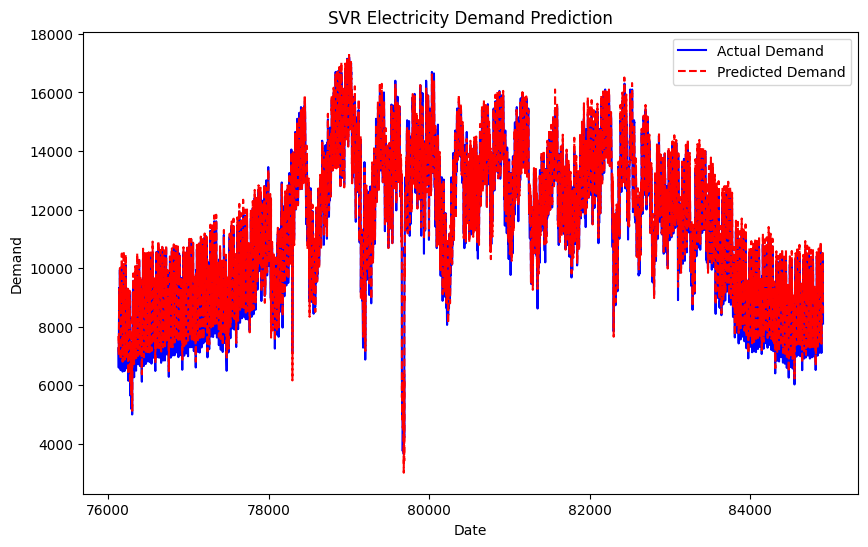

In [ ]:
from sklearn.svm import LinearSVR

svr=Pipeline([('scaler',StandardScaler()),('svm',LinearSVR(dual=False,loss='squared_epsilon_insensitive',C=2.0,max_iter=2000,random_state=42))])
svr.fit(xtrain, ytrain)
svmpred=svr.predict(xtest)

rmsesvr=np.sqrt(mean_squared_error(ytest,svmpred))
mapesvr=np.mean(np.abs((ytest-svmpred)/ytest))*100
print(f"RMSE:{rmsesvr:.2f} MW")
print(f"MAPE:{mapesvr:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(ytest.index,ytest,label='Actual Demand',color='Blue')
plt.plot(ytest.index,svmpred,label='Predicted Demand',color='Red',linestyle='--')
plt.title('SVR Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

**This is the last model, I learnt from Predictive Paradox. I implemented this in linear kernel. This is more robust to outliers. It is also very good at peaks.**

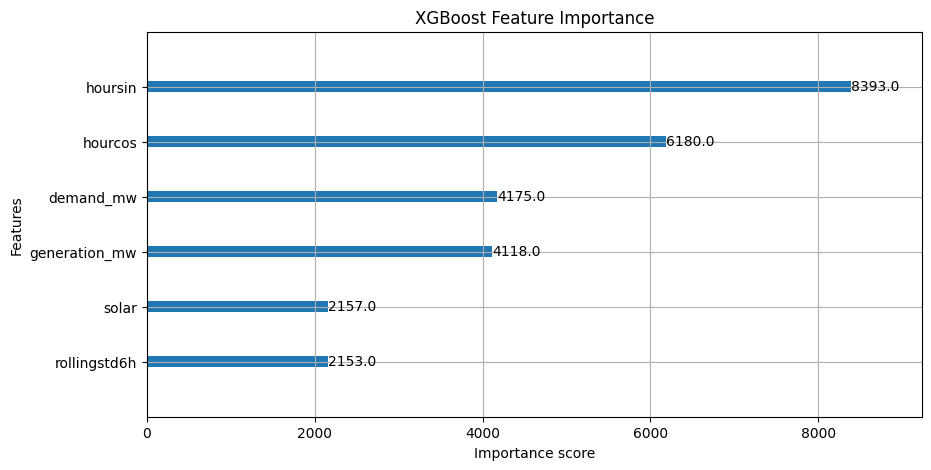

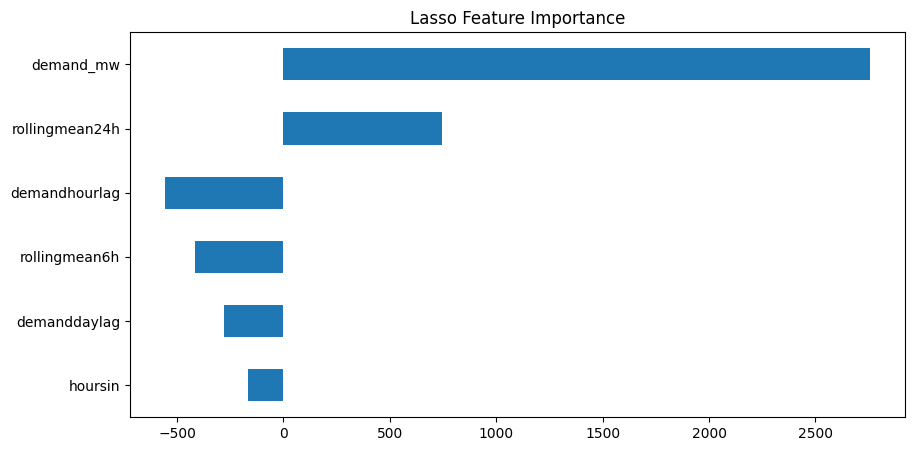

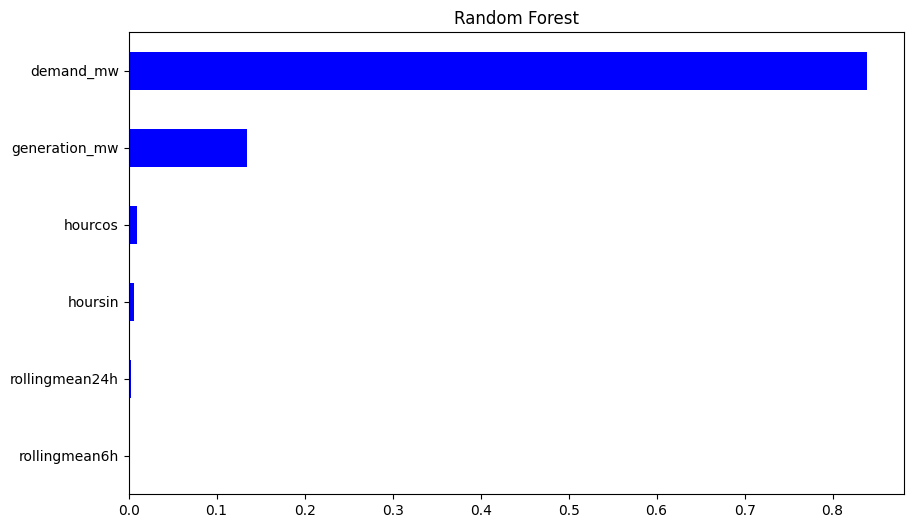

In [ ]:
xgb.plot_importance(model,max_num_features=6,importance_type='weight')
plt.title("XGBoost Feature Importance")
plt.show()

coefs=lasso.named_steps['model'].coef_
series=pd.Series(coefs,index=xtrain.columns)
impfeatures=series[series!=0].sort_values(key=abs,ascending=False).head(6)
impfeatures.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Lasso Feature Importance")
plt.show()

impfeatures=pd.Series(rf.feature_importances_,index=xtrain.columns).sort_values(ascending=False).head(6)
plt.figure(figsize=(10,6))
impfeatures.plot(kind='barh',color='blue')
plt.title("Random Forest")
plt.gca().invert_yaxis()
plt.show()

**Finally we get the values of MAPE for each model:
XgBoost: 2.26%; Random Forest: 2.23%; Linear Regression: 2.74%; Lasso Regularisation: 2.78%; Support Vector Regresssion: 2.88%**

**Here we are getting low(less than 5%) MAPE values. Because, we are only predicting the values after one hour. Hence the Forecasting turns out to be highly accurate. Of All the models Random Forest,XGBoost showed highest accuracy in terms of both RMSE and MAPE, followed by Lasso(L1) regression which had a better curve fit at peaks**